# Lab 5
#### MCA-A
#### 2547112

In [4]:
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

## Load the Dataset

In [5]:
diabetes = load_diabetes()

X = diabetes.data[:, [2]]

y = diabetes.target

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (442, 1)
Shape of y: (442,)


# Standardize the Features

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.29708846]
 [-1.08218016]
 [ 0.93453324]
 [-0.24377122]
 [-0.76494435]]


## Setting Params

In [7]:
# Init values for slope and intercept
m = 0.0
c = 0.0

# hyperparameters
learning_rate = 0.05
iterations = 1000

# Store loss values
loss_history = []

## Gradient Descent

In [10]:
for i in range(iterations):
    y_pred = m * X_scaled.flatten() + c
    error = y_pred - y 
    loss = np.mean(error ** 2)
    loss_history.append(loss)
    dm = (2 / len(X_scaled)) * np.dot(error, X_scaled.flatten())
    dc = (2 / len(X_scaled)) * np.sum(error)
    
    m -= learning_rate * dm
    c -= learning_rate * dc 
    
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss:.4f}, m = {m:.4f}, c = {c:.4f}")
        

Iteration 0: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 100: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 200: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 300: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 400: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 500: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 600: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 700: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 800: Loss = 3890.4566, m = 45.1600, c = 152.1335
Iteration 900: Loss = 3890.4566, m = 45.1600, c = 152.1335


## Print Final Parameters

In [11]:
print(f"\nFinal Parameters:\n\tSlope (m): {m:.4f}\n\tIntercept (c): {c:.4f}")


Final Parameters:
	Slope (m): 45.1600
	Intercept (c): 152.1335


## Plot the Regression Line

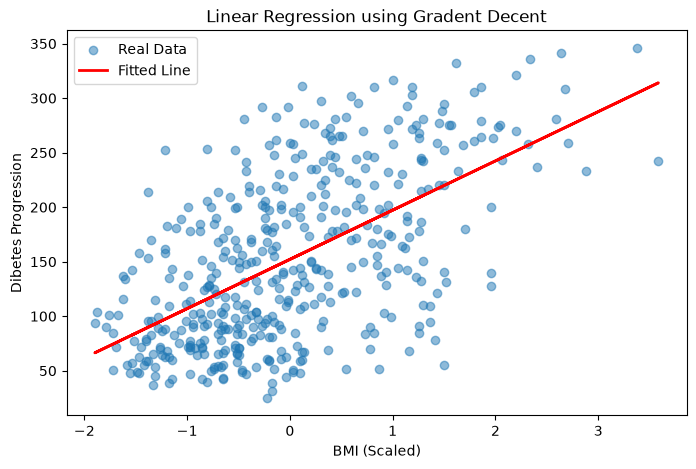

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(X_scaled, y, alpha=0.5, label='Real Data')

plt.plot(X_scaled, m * X_scaled.flatten() + c, color = 'red', linewidth = 2, label="Fitted Line")

plt.xlabel("BMI (Scaled)")
plt.ylabel("Dibetes Progression")
plt.title("Linear Regression using Gradent Decent")
plt.legend()
plt.show()

## Plot the Loss Curve

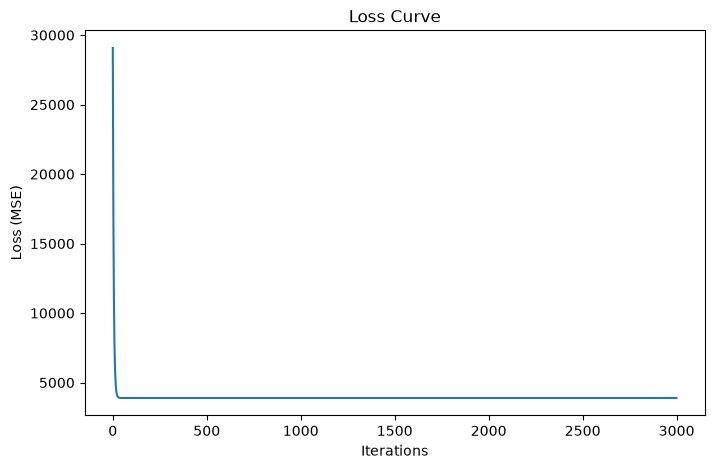

In [13]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve")
plt.show()

## 3D Visualization of the Initial Gradient Descent Path

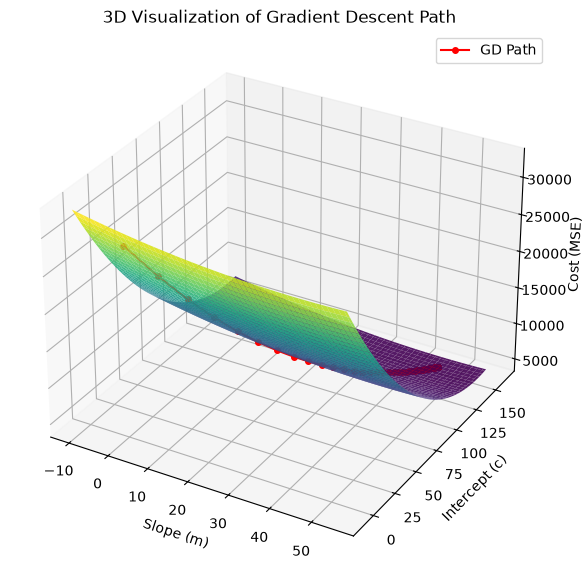

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# Redefine the compute_cost_single function to ensure it's available
def compute_cost_single(m_val, c_val, X_data, y_data):
    predictions = m_val * X_data.flatten() + c_val
    return np.mean((predictions - y_data) ** 2)

# --- Data Loading and Scaling (added for self-containment) ---
diabetes = load_diabetes()
X = diabetes.data[:, [2]]
y = diabetes.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# ----------------------------------------------------------------

m_viz = 0.0
c_viz = 0.0
learning_rate_viz = 0.05
iterations_viz = 1000

m_history = []
c_history = []
loss_history_viz = []

for i in range(iterations_viz):
    y_pred = m_viz * X_scaled.flatten() + c_viz
    error = y_pred - y
    loss = np.mean(error ** 2)

    m_history.append(m_viz)
    c_history.append(c_viz)
    loss_history_viz.append(loss)

    dm = (2 / len(X_scaled)) * np.dot(error, X_scaled.flatten())
    dc = (2 / len(X_scaled)) * np.sum(error)

    m_viz -= learning_rate_viz * dm
    c_viz -= learning_rate_viz * dc

# Create the cost surface for m and c (re-using the ranges from before)
# Adjusting ranges dynamically based on the history for better visualization
m_vals = np.linspace(min(m_history) - 10, max(m_history) + 10, 100)
c_vals = np.linspace(min(c_history) - 10, max(c_history) + 10, 100)
M, C = np.meshgrid(m_vals, c_vals)

# Calculate J_vals for the surface
J = np.array([compute_cost_single(mv, cv, X_scaled, y) for mv, cv in zip(M.flatten(), C.flatten())]).reshape(M.shape)

# 3D Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(M, C, J, cmap='viridis', alpha=0.9)

# Plot the path of gradient descent
ax.plot(m_history, c_history, loss_history_viz, color='red', marker='o', markersize=4, label='GD Path')

ax.set_xlabel('Slope (m)')
ax.set_ylabel('Intercept (c)')
ax.set_zlabel('Cost (MSE)')
ax.set_title('3D Visualization of Gradient Descent Path')
ax.legend()
plt.show()

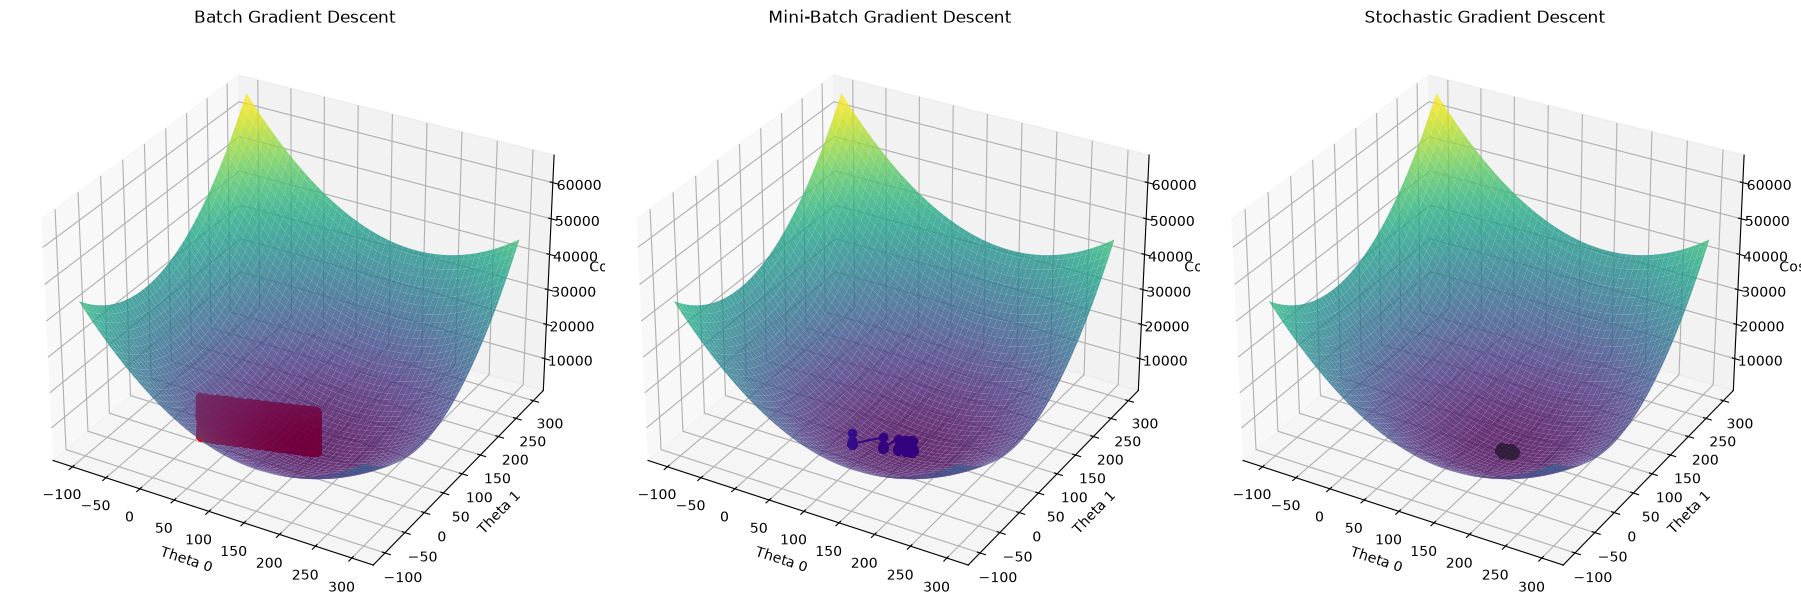

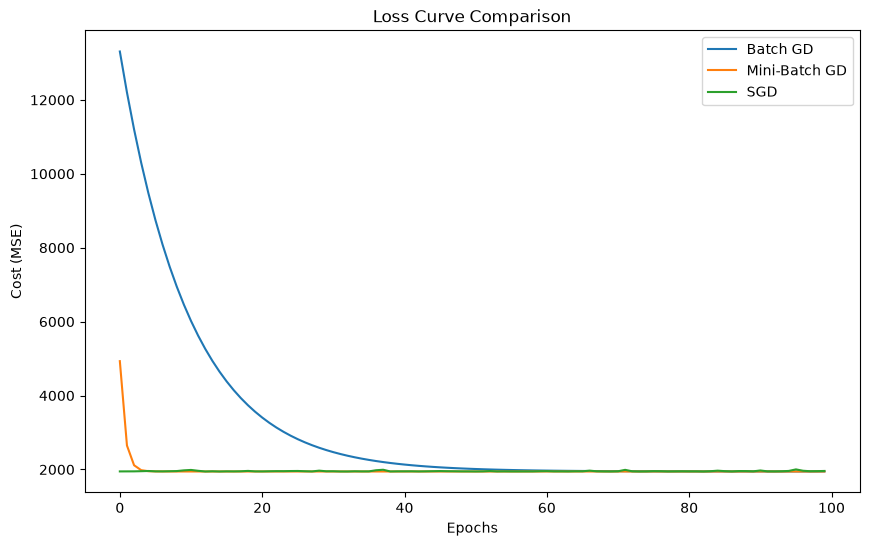

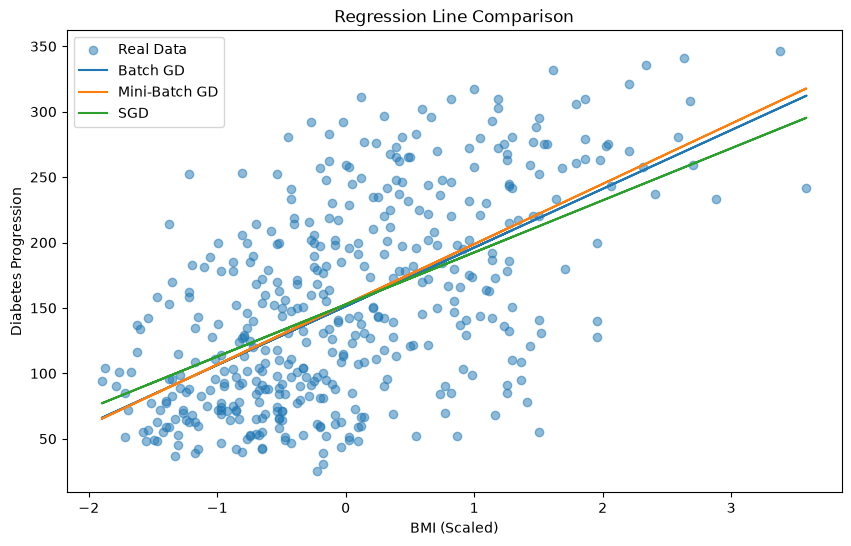


FINAL PARAMETERS

Batch GD
[[151.23277342]
 [ 44.89265874]]

Mini-Batch GD
[[152.73227752]
 [ 46.03042535]]

Stochastic GD
[[152.63322804]
 [ 39.7982217 ]]


In [15]:
# =========================================================
# COMPARISON OF:
# 1. Batch Gradient Descent
# 2. Mini-Batch Gradient Descent
# 3. Stochastic Gradient Descent
# USING DIABETES DATASET
# WITH 3D VISUALIZATION
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

# =========================================================
# STEP 1 — LOAD DATASET
# =========================================================

diabetes = load_diabetes()

# Use only one feature (BMI)
X = diabetes.data[:, [2]]

# Target
y = diabetes.target.reshape(-1, 1)

# Scale feature
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

m = len(X_scaled)

# Add bias column
X_bias = np.c_[np.ones((m, 1)), X_scaled]

# =========================================================
# STEP 2 — COST FUNCTION
# =========================================================

def compute_cost(theta, X, y):

    predictions = X.dot(theta)

    return (1 / (2 * len(y))) * np.sum((predictions - y) ** 2)

# =========================================================
# STEP 3 — BATCH GRADIENT DESCENT
# =========================================================

def batch_gradient_descent(X, y,
                           learning_rate=0.05,
                           epochs=100):

    theta = np.zeros((2, 1))

    history = []

    cost_history = []

    m = len(y)

    for epoch in range(epochs):

        predictions = X.dot(theta)

        gradients = (1 / m) * X.T.dot(predictions - y)

        theta = theta - learning_rate * gradients

        history.append(theta.copy())

        cost = compute_cost(theta, X, y)

        cost_history.append(cost)

    return theta, np.array(history), cost_history

# =========================================================
# STEP 4 — MINI-BATCH GRADIENT DESCENT
# =========================================================

def mini_batch_gradient_descent(X, y,
                                learning_rate=0.05,
                                epochs=100,
                                batch_size=32):

    theta = np.zeros((2, 1))

    history = []

    cost_history = []

    m = len(y)

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]

        y_shuffled = y[indices]

        for i in range(0, m, batch_size):

            X_batch = X_shuffled[i:i + batch_size]

            y_batch = y_shuffled[i:i + batch_size]

            predictions = X_batch.dot(theta)

            gradients = (1 / len(X_batch)) * \
                        X_batch.T.dot(predictions - y_batch)

            theta = theta - learning_rate * gradients

        history.append(theta.copy())

        cost = compute_cost(theta, X, y)

        cost_history.append(cost)

    return theta, np.array(history), cost_history

# =========================================================
# STEP 5 — STOCHASTIC GRADIENT DESCENT
# =========================================================

def stochastic_gradient_descent(X, y,
                                learning_rate=0.01,
                                epochs=100):

    theta = np.zeros((2, 1))

    history = []

    cost_history = []

    m = len(y)

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        X_shuffled = X[indices]

        y_shuffled = y[indices]

        for i in range(m):

            xi = X_shuffled[i:i+1]

            yi = y_shuffled[i:i+1]

            predictions = xi.dot(theta)

            gradients = xi.T.dot(predictions - yi)

            theta = theta - learning_rate * gradients

        history.append(theta.copy())

        cost = compute_cost(theta, X, y)

        cost_history.append(cost)

    return theta, np.array(history), cost_history

# =========================================================
# STEP 6 — TRAIN ALL MODELS
# =========================================================

theta_batch, history_batch, cost_batch = \
    batch_gradient_descent(X_bias, y)

theta_mini, history_mini, cost_mini = \
    mini_batch_gradient_descent(X_bias, y)

theta_sgd, history_sgd, cost_sgd = \
    stochastic_gradient_descent(X_bias, y)

# =========================================================
# STEP 7 — CREATE COST SURFACE
# =========================================================

theta0_vals = np.linspace(-100, 300, 100)

theta1_vals = np.linspace(-100, 300, 100)

T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

J_vals = np.zeros(T0.shape)

for i in range(T0.shape[0]):

    for j in range(T0.shape[1]):

        theta_temp = np.array([[T0[i, j]],
                               [T1[i, j]]])

        J_vals[i, j] = compute_cost(theta_temp,
                                    X_bias,
                                    y)

# =========================================================
# STEP 8 — 3D VISUALIZATION
# =========================================================

fig = plt.figure(figsize=(18, 6))

# -----------------------------
# BATCH GD
# -----------------------------

ax1 = fig.add_subplot(131, projection='3d')

ax1.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)

ax1.plot(history_batch[:, 0],
         history_batch[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_batch],
         color='red',
         marker='o')

ax1.set_title("Batch Gradient Descent")

ax1.set_xlabel("Theta 0")

ax1.set_ylabel("Theta 1")

ax1.set_zlabel("Cost")

# -----------------------------
# MINI-BATCH GD
# -----------------------------

ax2 = fig.add_subplot(132, projection='3d')

ax2.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)

ax2.plot(history_mini[:, 0],
         history_mini[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_mini],
         color='blue',
         marker='o')

ax2.set_title("Mini-Batch Gradient Descent")

ax2.set_xlabel("Theta 0")

ax2.set_ylabel("Theta 1")

ax2.set_zlabel("Cost")

# -----------------------------
# SGD
# -----------------------------

ax3 = fig.add_subplot(133, projection='3d')

ax3.plot_surface(T0, T1, J_vals,
                 cmap='viridis',
                 alpha=0.8)

ax3.plot(history_sgd[:, 0],
         history_sgd[:, 1],
         [compute_cost(h.reshape(2,1), X_bias, y)
          for h in history_sgd],
         color='green',
         marker='o')

ax3.set_title("Stochastic Gradient Descent")

ax3.set_xlabel("Theta 0")

ax3.set_ylabel("Theta 1")

ax3.set_zlabel("Cost")

plt.tight_layout()

plt.show()

# =========================================================
# STEP 9 — LOSS CURVE COMPARISON
# =========================================================

plt.figure(figsize=(10, 6))

plt.plot(cost_batch,
         label="Batch GD")

plt.plot(cost_mini,
         label="Mini-Batch GD")

plt.plot(cost_sgd,
         label="SGD")

plt.xlabel("Epochs")

plt.ylabel("Cost (MSE)")

plt.title("Loss Curve Comparison")

plt.legend()

plt.show()

# =========================================================
# STEP 10 — REGRESSION LINE COMPARISON
# =========================================================

plt.figure(figsize=(10, 6))

plt.scatter(X_scaled,
            y,
            alpha=0.5,
            label="Real Data")

# Batch GD line
plt.plot(X_scaled,
         X_bias.dot(theta_batch),
         label="Batch GD")

# Mini-Batch GD line
plt.plot(X_scaled,
         X_bias.dot(theta_mini),
         label="Mini-Batch GD")

# SGD line
plt.plot(X_scaled,
         X_bias.dot(theta_sgd),
         label="SGD")

plt.xlabel("BMI (Scaled)")

plt.ylabel("Diabetes Progression")

plt.title("Regression Line Comparison")

plt.legend()

plt.show()

# =========================================================
# STEP 11 — FINAL PARAMETERS
# 3D Visualization of the Initial Gradient Descent Path=========================================================

print("\n==============================")
print("FINAL PARAMETERS")
print("==============================")

print("\nBatch GD")
print(theta_batch)

print("\nMini-Batch GD")
print(theta_mini)

print("\nStochastic GD")
print(theta_sgd)